In [1]:
import os
os.chdir('../..')

In [10]:
from src.datasets import MaterialsProject

import numpy as np
import polars as pl
import pandas as pd
from sklearn.decomposition import PCA
from sklearn.manifold import TSNE
from sklearn.cluster import KMeans
from sklearn.metrics import silhouette_score, davies_bouldin_score, calinski_harabasz_score
import matplotlib.pyplot as plt

import re
from pathlib import Path


In [3]:
mp = MaterialsProject()
mp.load()

2026-02-20 13:39:44.079 | INFO     | src.datasets:load:333 - Loading cached Parquet data from data/Materials Project/stable_oxides.parquet...


material_id,formula_pretty,energy_per_atom,formation_energy_per_atom,raw_structure,crystal_system,space_group,density,a,b,c,alpha,beta,gamma,volume,num_sites,acsf_embedding,soap_embedding
str,str,f64,f64,str,str,str,f64,f64,f64,f64,f64,f64,f64,f64,i64,list[f64],list[f64]
"""mp-1274279""","""FeO""",-8.19051,-1.481519,"""{""@module"": ""pymatgen.core.str…","""Monoclinic""","""C2/m""",5.614899,3.102294,5.375696,5.443817,110.556657,91.096992,89.9466,84.988477,8,"[0.0, 0.0, … 0.0]","[0.0, 0.0, … 0.0]"
"""mp-19921""","""PbO""",-5.800276,-1.469972,"""{""@module"": ""pymatgen.core.str…","""Tetragonal""","""P4/nmm""",8.810225,3.999514,3.999514,5.259816,90.0,90.0,90.0,84.136627,4,"[0.0, 0.0, … 0.0]","[0.0, 0.0, … 0.0]"
"""mp-2097""","""SnO""",-6.108469,-1.629702,"""{""@module"": ""pymatgen.core.str…","""Tetragonal""","""P4/nmm""",6.294343,3.813695,3.813695,4.8869133,90.0,90.0,90.0,71.076593,4,"[0.0, 0.0, … 0.0]","[0.0, 0.0, … 0.0]"
"""mp-1692""","""CuO""",-5.466379,-0.942795,"""{""@module"": ""pymatgen.core.str…","""Tetragonal""","""P4_2/mmc""",6.1556,2.879501,2.879545,5.176397,89.806512,89.806349,89.222525,42.916449,4,"[0.0, 0.0, … 0.0]","[0.0, 0.0, … 0.0]"
"""mp-1336""","""PdO""",-5.853748,-0.789826,"""{""@module"": ""pymatgen.core.str…","""Tetragonal""","""P4_2/mmc""",8.117606,3.053604,3.053604,5.371257,90.0,90.0,90.0,50.084274,4,"[0.0, 0.0, … 0.0]","[0.0, 0.0, … 0.0]"
…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…
"""mp-24129""","""MnH4(BrO)2""",-5.299537,-1.309259,"""{""@module"": ""pymatgen.core.str…","""Monoclinic""","""C2/m""",2.976894,3.963651,6.006202,6.006203,95.912312,96.949439,96.949428,139.885532,9,"[4.619654, 0.736364, … 0.0]","[0.100292, 0.26796, … 0.0]"
"""mp-23880""","""FeH4(ClO)2""",-5.265791,-1.305381,"""{""@module"": ""pymatgen.core.str…","""Monoclinic""","""C2/m""",2.287095,5.714367,5.714367,3.721117,82.486963,82.486963,97.148948,118.187118,9,"[5.545048, 0.773538, … 0.0]","[0.100956, 0.268515, … 0.0]"
"""mp-23853""","""CoH4(ClO)2""",-5.045306,-1.233407,"""{""@module"": ""pymatgen.core.str…","""Monoclinic""","""C2/m""",2.424991,3.603494,5.686069,5.686069,97.465063,96.908777,96.908772,113.58114,9,"[5.775085, 0.776909, … 0.0]","[0.101054, 0.268578, … 0.0]"


# Analyzing number of Clusters

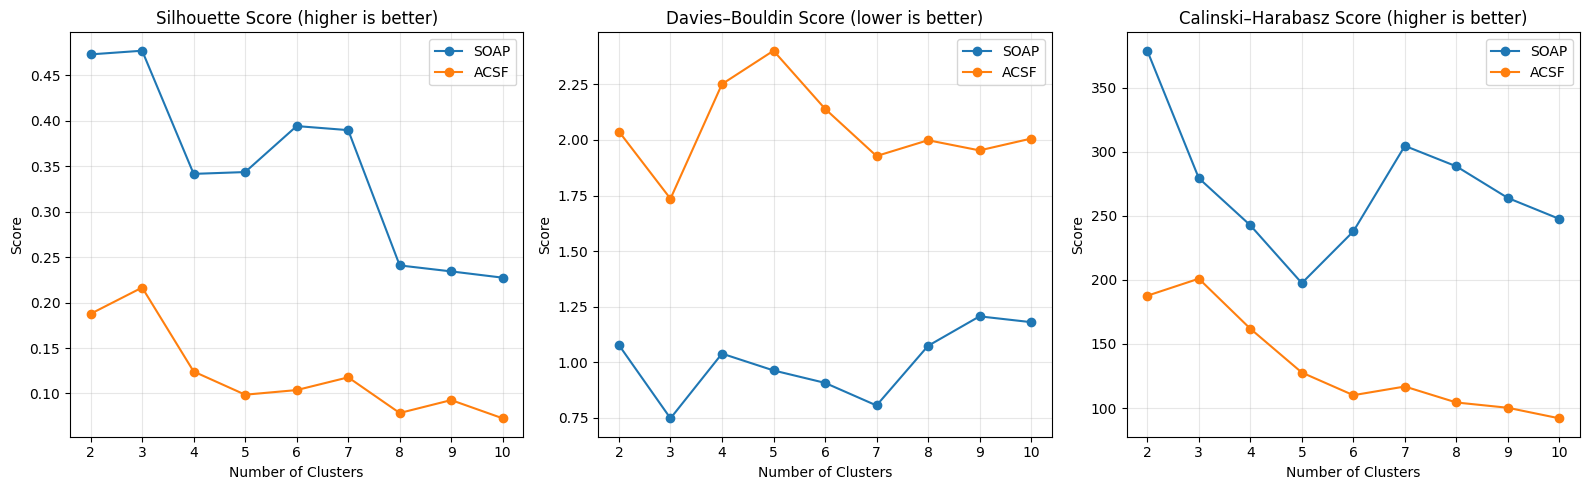

In [4]:

# ---------- Prepare data ----------
X = {
    "SOAP": np.array(mp.df["soap_embedding"].to_list()),
    "ACSF": np.array(mp.df["acsf_embedding"].to_list()),
}

cluster_range = range(2, 11)


# ---------- Clustering evaluation ----------
def evaluate_clustering(X, cluster_range):
    """Compute clustering metrics across different k."""
    metrics = {
        "silhouette": [],
        "davies_bouldin": [],
        "calinski_harabasz": [],
    }

    for k in cluster_range:
        kmeans = KMeans(n_clusters=k, random_state=42, n_init="auto")
        labels = kmeans.fit_predict(X)

        metrics["silhouette"].append(silhouette_score(X, labels))
        metrics["davies_bouldin"].append(davies_bouldin_score(X, labels))
        metrics["calinski_harabasz"].append(calinski_harabasz_score(X, labels))

    return metrics


# ---------- Run evaluation ----------
results = {
    name: evaluate_clustering(data, cluster_range)
    for name, data in X.items()
}


# ---------- Plotting ----------
metric_titles = {
    "silhouette": "Silhouette Score (higher is better)",
    "davies_bouldin": "Davies–Bouldin Score (lower is better)",
    "calinski_harabasz": "Calinski–Harabasz Score (higher is better)",
}

fig, axes = plt.subplots(1, 3, figsize=(16, 5))

for ax, metric in zip(axes, metric_titles):
    for name in results:
        ax.plot(cluster_range, results[name][metric], marker="o", label=name)

    ax.set_title(metric_titles[metric])
    ax.set_xlabel("Number of Clusters")
    ax.set_ylabel("Score")
    ax.grid(alpha=0.3)
    ax.legend()

plt.tight_layout()
plt.show()

Best number of clusters is: 3

# Clustering

In [5]:
X_soap = np.array(mp.df["soap_embedding"].to_list())
X_acsf = np.array(mp.df["acsf_embedding"].to_list())

model = KMeans(n_clusters=3, random_state=42, n_init=10)
labels_soap = model.fit_predict(X_soap)
labels_acsf = model.fit_predict(X_acsf)

pca = PCA(n_components=2, random_state=42)
pca_soap = pca.fit_transform(X_soap)
pca_acsf = pca.fit_transform(X_acsf)

tsne = TSNE(n_components=2, random_state=42)
tsne_soap = tsne.fit_transform(X_soap)
tsne_acsf = tsne.fit_transform(X_acsf)

mp.df = mp.df.with_columns(
    soap_labels = labels_soap,
    acsf_labels = labels_acsf,
    
    soap_pca_x = pca_soap[:, 0],
    soap_pca_y = pca_soap[:, 1],
    acsf_pca_x = pca_acsf[:, 0],
    acsf_pca_y = pca_acsf[:, 1],
    
    soap_tsne_x = tsne_soap[:, 0],
    soap_tsne_y = tsne_soap[:, 1],
    acsf_tsne_x = tsne_acsf[:, 0],
    acsf_tsne_y = tsne_acsf[:, 1]
)

df = mp.df.drop(["soap_embedding", "acsf_embedding"])
df.write_csv('report/materials_project/csv/mp_clusterlabels.csv')

In [6]:
df.head(5)

material_id,formula_pretty,energy_per_atom,formation_energy_per_atom,raw_structure,crystal_system,space_group,density,a,b,c,alpha,beta,gamma,volume,num_sites,soap_labels,acsf_labels,soap_pca_x,soap_pca_y,acsf_pca_x,acsf_pca_y,soap_tsne_x,soap_tsne_y,acsf_tsne_x,acsf_tsne_y
str,str,f64,f64,str,str,str,f64,f64,f64,f64,f64,f64,f64,f64,i64,i32,i32,f64,f64,f64,f64,f32,f32,f32,f32
"""mp-1274279""","""FeO""",-8.19051,-1.481519,"""{""@module"": ""pymatgen.core.str…","""Monoclinic""","""C2/m""",5.614899,3.102294,5.375696,5.443817,110.556657,91.096992,89.9466,84.988477,8,1,0,44.26912,-3.96765,5.380828,1.131248,32.459087,6.984276,23.542862,-3.485822
"""mp-19921""","""PbO""",-5.800276,-1.469972,"""{""@module"": ""pymatgen.core.str…","""Tetragonal""","""P4/nmm""",8.810225,3.999514,3.999514,5.259816,90.0,90.0,90.0,84.136627,4,0,2,-2.827535,-4.714641,0.831428,-0.940755,-1.152455,-2.36151,-12.503512,2.633254
"""mp-2097""","""SnO""",-6.108469,-1.629702,"""{""@module"": ""pymatgen.core.str…","""Tetragonal""","""P4/nmm""",6.294343,3.813695,3.813695,4.8869133,90.0,90.0,90.0,71.076593,4,0,2,3.657751,-4.591494,1.459491,-0.608438,7.461085,4.493946,12.112691,-1.876178
"""mp-1692""","""CuO""",-5.466379,-0.942795,"""{""@module"": ""pymatgen.core.str…","""Tetragonal""","""P4_2/mmc""",6.1556,2.879501,2.879545,5.176397,89.806512,89.806349,89.222525,42.916449,4,1,0,40.177808,-4.472641,5.236903,0.801468,19.654606,-2.710176,16.829086,-8.54473
"""mp-1336""","""PdO""",-5.853748,-0.789826,"""{""@module"": ""pymatgen.core.str…","""Tetragonal""","""P4_2/mmc""",8.117606,3.053604,3.053604,5.371257,90.0,90.0,90.0,50.084274,4,1,0,25.406681,-4.231383,3.720457,0.337488,27.371416,6.494433,20.110836,-10.143901


In [7]:
def plot_clusters(df, dim_reducer):
    fig, axes = plt.subplots(1, 2, figsize=(14, 6))

    scatter_soap = axes[0].scatter(
        df[f"soap_{dim_reducer}_x"], 
        df[f"soap_{dim_reducer}_y"], 
        c=df["soap_labels"], 
        cmap='viridis',   
        alpha=0.7,      
        edgecolor='k', 
        s=40    
    )

    axes[0].set_title(f"SOAP {dim_reducer.upper()} Clustering (k=3)", fontsize=14)
    axes[0].set_xlabel("Principal Component 1")
    axes[0].set_ylabel("Principal Component 2")

    scatter_acsf = axes[1].scatter(
        df[f"acsf_{dim_reducer}_x"], 
        df[f"acsf_{dim_reducer}_y"], 
        c=df["acsf_labels"], 
        cmap='viridis', 
        alpha=0.7,
        edgecolor='k',
        s=40
    )

    axes[1].set_title(f"ACSF {dim_reducer.upper()} Clustering (k=3)", fontsize=14)
    axes[1].set_xlabel("Principal Component 1")
    axes[1].set_ylabel("Principal Component 2")

    plt.tight_layout()
    plt.legend(*scatter_soap.legend_elements(), title="Clusters", loc="upper right")
    plt.savefig(f"report/materials_project/{dim_reducer}_clusters_comparison.png", dpi=300)
    plt.show()

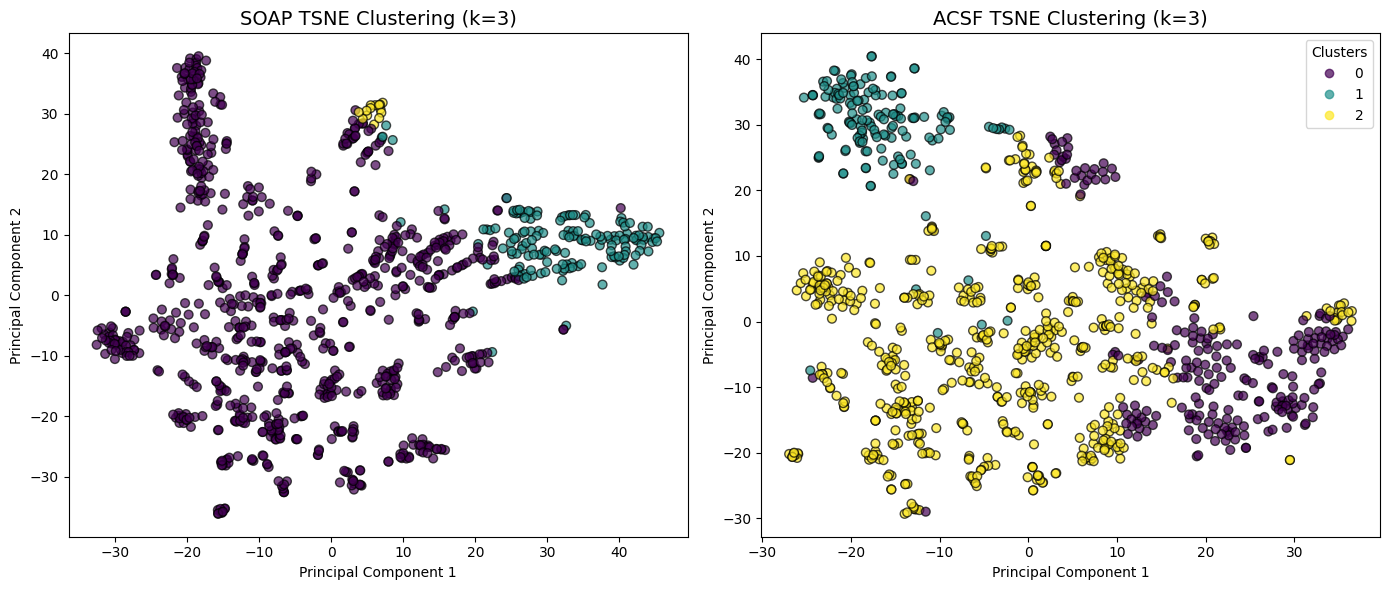

In [8]:
plot_clusters(df, "tsne")

In [13]:
import polars as pl
import pandas as pd
from pymatgen.core import Composition

def generate_materials_cluster_report(df: pl.DataFrame, label_col: str, output_csv: str):
    """
    Generates a detailed summary of cluster profiles including continuous averages, 
    categorical percentages, and elemental compositions.
    """
    print(f"Generating report for: '{label_col}'...")
    
    # ==========================================
    # 1. Continuous Properties (Averages)
    # ==========================================
    properties_to_analyze = [
        "energy_per_atom", "formation_energy_per_atom", "density",
        "a", "b", "c", "alpha", "beta", "gamma", "volume", "num_sites"
    ]
    
    valid_props = [p for p in properties_to_analyze if p in df.columns]
    
    summary = (
        df.group_by(label_col)
        .agg(
            [pl.col(p).mean().alias(f"avg_{p}") for p in valid_props] +
            [pl.len().alias("material_count")]
        )
        .sort(label_col)
        .to_pandas()
        .set_index(label_col)
    )
    
    # ==========================================
    # 2. Categorical Distributions (Percentages)
    # ==========================================
    categorical_dfs = []
    for cat_col in ["crystal_system", "space_group"]:
        if cat_col in df.columns:
            pivot = (
                df.group_by([label_col, cat_col])
                .len()
                .pivot(on=cat_col, index=label_col, values="len")
                .fill_null(0)
                .to_pandas()
                .set_index(label_col)
            )
            # Calculate percentages across the rows (clusters)
            pct = pivot.div(pivot.sum(axis=1), axis=0) * 100
            pct.columns = [f"pct_{cat_col}_{c}" for c in pct.columns]
            categorical_dfs.append(pct)

    # ==========================================
    # 3. Element Composition (Parsing Formula)
    # ==========================================
    print("Calculating element compositions...")
    def get_element_counts(formula):
        try:
            # Parses formula (e.g., "Fe2O3") into a dictionary: {"Fe": 2.0, "O": 3.0}
            return Composition(formula).as_dict()
        except:
            return {}

    # Extract elements and construct a horizontal dataframe of counts
    element_dicts = [get_element_counts(f) for f in df["formula_pretty"].to_list()]
    element_df = pl.from_dicts(element_dicts).fill_null(0.0)
    
    # Concatenate the cluster labels with the element counts
    analysis_df = pl.concat([df.select(label_col), element_df], how="horizontal")
    cluster_sums = analysis_df.group_by(label_col).sum().sort(label_col)
    
    # Calculate the percentage of each element relative to the total elements in that cluster
    element_cols = [c for c in cluster_sums.columns if c != label_col]
    total_elements = cluster_sums.select(element_cols).sum_horizontal()
    
    composition = (
        cluster_sums.with_columns(
            [(pl.col(c) / total_elements * 100).alias(f"pct_element_{c}") for c in element_cols]
        )
        .select([label_col] + [f"pct_element_{c}" for c in element_cols])
        .to_pandas()
        .set_index(label_col)
    )

    # ==========================================
    # 4. Combine and Export
    # ==========================================
    # Combine the averages, categoricals, and elemental compositions side-by-side
    final_report = pd.concat([summary] + categorical_dfs + [composition], axis=1)
    final_report = final_report.fillna(0).round(3)
    
    final_report.to_csv(output_csv)
    print(f"Saved profile to: {output_csv}\n")
    return final_report

# ==========================================
# 5. Execution for SOAP and ACSF
# ==========================================
import os

# Ensure the output directory exists
os.makedirs("report/materials_project/csv", exist_ok=True)

# Generate report for SOAP
generate_materials_cluster_report(
    df, 
    label_col="soap_labels", 
    output_csv="report/materials_project/csv/soap_profile.csv"
)

# Generate report for ACSF
generate_materials_cluster_report(
    df, 
    label_col="acsf_labels", 
    output_csv="report/materials_project/csv/acsf_profile.csv"
)

Generating report for: 'soap_labels'...
Calculating element compositions...
Saved profile to: report/materials_project/csv/soap_profile.csv

Generating report for: 'acsf_labels'...
Calculating element compositions...
Saved profile to: report/materials_project/csv/acsf_profile.csv



,avg_energy_per_atom,avg_formation_energy_per_atom,avg_density,avg_a,avg_b,avg_c,avg_alpha,avg_beta,avg_gamma,avg_volume,...,pct_element_Sm,pct_element_Pr,pct_element_Ac,pct_element_U,pct_element_Yb,pct_element_Se,pct_element_Th,pct_element_Y,pct_element_Np,pct_element_Lu
acsf_labels,,,,,,,,,,,,,,,,,,,,,
0,-7.070,-2.116,5.728,4.576,5.118,6.698,81.598,81.886,81.075,129.428,...,0.255,0.128,0.000,0.128,0.766,0.128,0.128,0.639,0.128,0.639
1,-6.208,-2.718,4.468,7.244,7.441,9.589,83.180,86.277,85.662,455.883,...,0.240,0.080,0.080,0.080,0.080,0.480,0.000,0.560,0.080,0.320
2,-6.394,-1.984,5.337,6.324,6.910,8.916,91.618,91.413,86.026,382.255,...,0.586,1.252,0.053,0.320,0.266,2.104,0.213,0.479,0.107,0.160
